# Staged SMAC leaf-size policy: 3 → 2 → 1

This runs 500 target-function evaluations on the same SynthACticBench problem and instances as `min_leaf_1_vs_3.ipynb`. The surrogate uses `min_samples_leaf=3` before trial 150, `2` before trial 300, and `1` afterwards. The final plot overlays this run with the three completed 500-trial fixed-policy runs.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from carps.utils.running import make_problem
from carps.utils.trials import TrialInfo
from omegaconf import OmegaConf
from smac import AlgorithmConfigurationFacade as ACFacade
from smac import Scenario
from smac.callback import Callback

EXPERIMENT_DIR = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench")
PROBLEM_CONFIG = (
    EXPERIMENT_DIR.parents[1]
    / "external/SynthACticBench/synthacticbench/configs/problem/"
    "SynthACticBench/O1-DeterministicObjective.yaml"
)
N_TRIALS = 500
SMAC_SEED = 0
N_INSTANCES = 10
INSTANCE_SEED = 0

rng = np.random.default_rng(INSTANCE_SEED)
instance_map = {
    f"i{i}": float(offset)
    for i, offset in enumerate(rng.normal(0, 2, N_INSTANCES))
}

In [2]:
def leaf_size_for_trial(completed_trials):
    if completed_trials < 150:
        return 3
    if completed_trials < 300:
        return 2
    return 1


class StagedLeafSizeCallback(Callback):
    def __init__(self):
        super().__init__()
        self.transitions = []
        self.last_leaf_size = None

    def on_next_configurations_start(self, config_selector):
        completed_trials = len(config_selector._runhistory)
        leaf_size = leaf_size_for_trial(completed_trials)
        config_selector._model._rf_opts["min_samples_leaf"] = leaf_size
        if leaf_size != self.last_leaf_size:
            self.transitions.append((completed_trials, leaf_size))
            self.last_leaf_size = leaf_size

In [3]:
def run_staged_policy():
    problem = make_problem(OmegaConf.load(PROBLEM_CONFIG))
    problem.set_instances(instance_map)

    def target_function(config, instance, seed=0):
        trial = TrialInfo(config=config, instance=instance, seed=seed)
        return float(problem.evaluate(trial).cost)

    scenario = Scenario(
        configspace=problem.configspace,
        deterministic=True,
        n_trials=N_TRIALS,
        seed=SMAC_SEED,
        instances=list(instance_map),
        output_directory=EXPERIMENT_DIR / "smac_output/staged_leaf_3_2_1",
    )
    model = ACFacade.get_model(scenario=scenario, min_samples_leaf=3)
    callback = StagedLeafSizeCallback()
    smac = ACFacade(
        scenario=scenario,
        target_function=target_function,
        model=model,
        callbacks=[callback],
        overwrite=True,
    )
    incumbent = smac.optimize()

    ordered_trials = sorted(
        smac.runhistory.items(),
        key=lambda item: (item[1].starttime, item[1].endtime),
    )
    objective_values = [
        float(value.cost) - instance_map[key.instance]
        for key, value in ordered_trials
    ]
    return {
        "best_so_far": np.minimum.accumulate(objective_values),
        "incumbent": dict(incumbent),
        "incumbent_cost": float(smac.runhistory.get_cost(incumbent)),
        "n_trials": len(smac.runhistory),
        "transitions": callback.transitions,
    }


staged_result = run_staged_policy()
staged_result

Lower bound: -100, 10
[WARNING][abstract_encoder.py:74] We strongly encourage to use instance features when using instances.If no instance features are passed, the runhistory encoder can not distinguish between different instances and therefore returns the same data points with different values, all of which are used to train the surrogate model.
Consider using instance indices as features.
[INFO][abstract_initial_design.py:143] Using 1 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config 76d066 as new incumbent because there are no incumbents yet.


[INFO][abstract_intensifier.py:630] Added config 84b2f1 and rejected config 76d066 as incumbent because it is not better than the incumbents on 2 instances: 
[INFO][abstract_intensifier.py:630] Added config 2f2270 and rejected config 84b2f1 as incumbent because it is not better than the incumbents on 7 instances: 
[INFO][abstract_intensifier.py:630] Added config 036c87 and rejected config 2f2270 as incumbent because it is not better than the incumbents on 10 instances: 
[INFO][smbo.py:334] Finished 50 trials.
[INFO][abstract_intensifier.py:630] Added config e2abc1 and rejected config 036c87 as incumbent because it is not better than the incumbents on 10 instances: 
[INFO][smbo.py:334] Finished 100 trials.
[INFO][abstract_intensifier.py:630] Added config 83a07e and rejected config e2abc1 as incumbent because it is not better than the incumbents on 10 instances: 
[INFO][abstract_intensifier.py:630] Added config c03f3c and rejected config 83a07e as incumbent because it is not better than 

{'best_so_far': array([ 1.85153315e+01,  1.85153315e+01, -7.49397890e+04, -7.49397890e+04,
        -7.49397890e+04, -7.49397890e+04, -7.49397890e+04, -7.49397890e+04,
        -7.49397890e+04, -7.49397890e+04, -7.49397890e+04, -7.49397890e+04,
        -7.49397890e+04, -8.61406692e+04, -8.61406692e+04, -8.61406692e+04,
        -8.61406692e+04, -8.61406692e+04, -8.61406692e+04, -8.61406692e+04,
        -8.61406692e+04, -8.61406692e+04, -8.61406692e+04, -8.61406692e+04,
        -8.61406692e+04, -8.61406692e+04, -8.61406692e+04, -8.61406692e+04,
        -8.61406692e+04, -8.61406692e+04, -8.61406692e+04, -8.61406692e+04,
        -8.61406692e+04, -8.61406692e+04, -8.61406692e+04, -1.83365939e+05,
        -1.83365939e+05, -1.83365939e+05, -1.83365939e+05, -1.83365939e+05,
        -1.83365939e+05, -1.83365939e+05, -1.83365939e+05, -1.83365939e+05,
        -1.83365939e+05, -1.83365939e+05, -1.83365939e+05, -1.83365939e+05,
        -1.83365939e+05, -1.83365939e+05, -1.83365939e+05, -1.83365939e+0

## Load the fixed-policy results

Run `min_leaf_1_vs_3.ipynb` first. This loader deliberately accepts only completed 500-trial histories, so older 200-trial results cannot accidentally enter the comparison.

In [4]:
def load_fixed_trace(leaf_size):
    runhistories = list(
        (EXPERIMENT_DIR / "smac_output" / f"min_leaf_{leaf_size}").glob(
            "*/0/runhistory.json"
        )
    )
    completed = []
    for path in runhistories:
        data = json.loads(path.read_text())
        if data["stats"]["finished"] == N_TRIALS and len(data["data"]) == N_TRIALS:
            completed.append((path, data))
    if not completed:
        raise FileNotFoundError(
            f"No completed {N_TRIALS}-trial fixed leaf-{leaf_size} run found. "
            "Run min_leaf_1_vs_3.ipynb first."
        )

    path, runhistory = max(completed, key=lambda item: item[0].stat().st_mtime)
    trials = sorted(runhistory["data"], key=lambda row: (row["starttime"], row["endtime"]))
    objective_values = [
        float(row["cost"]) - instance_map[row["instance"]]
        for row in trials
    ]
    return np.minimum.accumulate(objective_values)


fixed_traces = {leaf_size: load_fixed_trace(leaf_size) for leaf_size in (1, 2, 3)}

## Fixed policies versus the staged policy

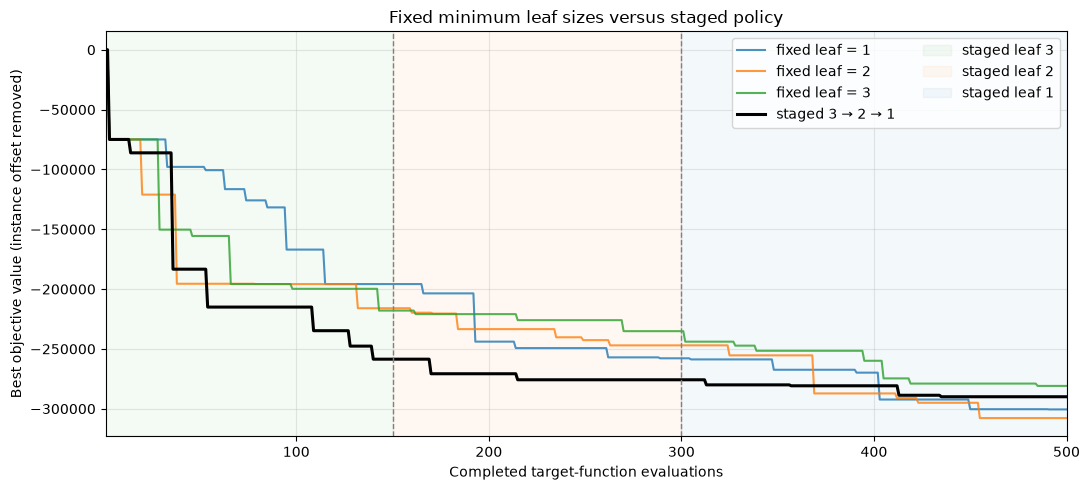

Observed staged transitions (completed trials, new leaf size):
[(0, 3), (150, 2), (300, 1)]


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

for leaf_size, trace in fixed_traces.items():
    ax.plot(range(1, len(trace) + 1), trace, label=f"fixed leaf = {leaf_size}", alpha=0.8)

ax.plot(
    range(1, len(staged_result["best_so_far"]) + 1),
    staged_result["best_so_far"],
    color="black",
    linewidth=2.2,
    label="staged 3 → 2 → 1",
)
ax.axvline(150, color="grey", linestyle="--", linewidth=1)
ax.axvline(300, color="grey", linestyle="--", linewidth=1)
ax.axvspan(0, 150, color="C2", alpha=0.05, label="staged leaf 3")
ax.axvspan(150, 300, color="C1", alpha=0.05, label="staged leaf 2")
ax.axvspan(300, N_TRIALS, color="C0", alpha=0.05, label="staged leaf 1")
ax.set(
    xlabel="Completed target-function evaluations",
    ylabel="Best objective value (instance offset removed)",
    title="Fixed minimum leaf sizes versus staged policy",
    xlim=(1, N_TRIALS),
)
ax.grid(alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

print("Observed staged transitions (completed trials, new leaf size):")
print(staged_result["transitions"])